## Modelagem de Machine Learning

## Sistema de priorização de ativos da B3 para uma fintech

Este notebook constrói e avalia modelos de classificação para estimar se um ativo da B3 tende a superar o benchmark em uma janela futura de 60 pregões.

A proposta **não é recomendar compra ou venda automaticamente**. O objetivo é criar uma camada de apoio à decisão para uma fintech/corretora, combinando:

- retorno histórico;
- volatilidade;
- liquidez;
- drawdown;
- score probabilístico;
- avaliação de modelos.

> **Aviso:** este projeto é educacional e analítico. Não constitui recomendação de investimento.

## 1. Configuração inicial

Nesta etapa importamos as bibliotecas, configuramos a visualização dos dados e criamos as pastas onde serão salvos gráficos e tabelas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Configurações gerais
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

# Pastas de saída
IMAGES_DIR = Path("../images")
TABLES_DIR = Path("../reports/tables")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


## 2. Carregamento da base

A base `b3_features.csv` foi gerada nas etapas anteriores do projeto, a partir das séries históricas da B3.

Cada linha representa um ativo em uma data específica, com variáveis históricas calculadas até aquela data e um alvo futuro indicando se o ativo superou o benchmark nos próximos 60 pregões.

In [2]:
possible_paths = [
    Path("../data/processed/b3_features.csv"),
    Path("data/processed/b3_features.csv"),
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Arquivo b3_features.csv não encontrado. "
        "Verifique se ele está em data/processed/b3_features.csv."
    )

df = pd.read_csv(data_path)
df["data_pregao"] = pd.to_datetime(df["data_pregao"])

print("Base carregada com sucesso.")
print("Caminho usado:", data_path)
print("Shape:", df.shape)
print("Período:", df["data_pregao"].min(), "até", df["data_pregao"].max())
print("Quantidade de ativos:", df["ticker"].nunique())

df.head()

Base carregada com sucesso.
Caminho usado: ..\data\processed\b3_features.csv
Shape: (57200, 35)
Período: 2019-01-11 00:00:00 até 2025-10-02 00:00:00
Quantidade de ativos: 35


,data_pregao,ticker,cod_bdi,tipo_mercado,nome_empresa,especificacao,preco_abertura,preco_maximo,preco_minimo,preco_medio,preco_fechamento,numero_negocios,quantidade_negociada,volume_negociado,retorno_1d,retorno_7d,retorno_21d,retorno_63d,retorno_126d,retorno_252d,volatilidade_21d,volatilidade_63d,volatilidade_126d,volume_medio_21d,volume_medio_63d,negocios_medio_21d,amplitude_intradiaria,amplitude_media_21d,drawdown_252d,distancia_maxima_252d,sharpe_aprox_63d,retorno_futuro_60d,retorno_futuro_60d_benchmark,retorno_1d_benchmark,target_supera_benchmark_60d
0,2019-01-11,ABEV3,2,10,AMBEV S/A,ON,17.0200,17.2900,16.8800,17.0700,17.2900,82408,73632000,125714492000,0.0261,0.0706,0.0732,-0.0325,-0.0603,-0.2029,0.3030,0.3170,0.2698,34525939366.6667,34787468426.9841,32188.0000,0.0237,0.0283,-0.2876,-0.2876,-0.1024,0.0150,0.0233,-0.0004,0
1,2019-01-14,ABEV3,2,10,AMBEV S/A,ON,17.2400,17.6600,17.1000,17.4900,17.5400,48520,31707300,55460853100,0.0145,0.0741,0.1038,-0.0062,-0.0304,-0.1932,0.2986,0.3175,0.2696,35594422319.0476,35212084461.9048,32616.1429,0.0319,0.0284,-0.2773,-0.2773,-0.0196,-0.0165,0.0019,0.0092,0
2,2019-01-15,ABEV3,2,10,AMBEV S/A,ON,17.5700,17.7900,17.3000,17.6600,17.7000,46403,35536600,62776312300,0.0091,0.0695,0.1097,-0.0167,-0.0269,-0.1813,0.2989,0.3155,0.2698,37204774180.9524,35444913892.0635,33789.8095,0.0277,0.0288,-0.2707,-0.2707,-0.0528,-0.0362,-0.0121,-0.0066,0
3,2019-01-16,ABEV3,2,10,AMBEV S/A,ON,17.7000,17.8400,17.5600,17.7000,17.8000,30619,19990600,35398484900,0.0056,0.0801,0.1160,0.0183,-0.0061,-0.1797,0.2983,0.3102,0.2690,37293064604.7619,35456668474.6032,33633.3810,0.0157,0.0286,-0.2666,-0.2666,0.0590,-0.0213,-0.0147,0.0060,0
4,2019-01-17,ABEV3,2,10,AMBEV S/A,ON,17.6800,17.9100,17.4800,17.7400,17.8500,42784,22422400,39777918400,0.0028,0.1053,0.0938,0.0378,-0.0214,-0.1759,0.2913,0.3084,0.2678,38139026838.0952,35778870525.3968,34570.7619,0.0241,0.0288,-0.2645,-0.2645,0.1226,-0.0179,-0.0105,0.0090,0


## 3. Definição do problema de modelagem

O problema foi formulado como uma **classificação binária**.

A variável alvo é:

`target_supera_benchmark_60d`

- `1`: o ativo superou o benchmark nos próximos 60 pregões;
- `0`: o ativo não superou o benchmark nos próximos 60 pregões.

Um ponto crítico é evitar **vazamento de dados**. Portanto, variáveis futuras como `retorno_futuro_60d` e `retorno_futuro_60d_benchmark` não entram como explicativas.

In [3]:
target_col = "target_supera_benchmark_60d"

feature_cols = [
    "retorno_1d",
    "retorno_7d",
    "retorno_21d",
    "retorno_63d",
    "retorno_126d",
    "retorno_252d",
    "volatilidade_21d",
    "volatilidade_63d",
    "volatilidade_126d",
    "volume_medio_21d",
    "volume_medio_63d",
    "negocios_medio_21d",
    "amplitude_media_21d",
    "drawdown_252d",
    "distancia_maxima_252d",
    "sharpe_aprox_63d",
    "retorno_1d_benchmark",
]

# Validação das colunas
missing_cols = [col for col in feature_cols + [target_col, "data_pregao", "ticker"] if col not in df.columns]

if missing_cols:
    raise ValueError(f"As seguintes colunas não foram encontradas na base: {missing_cols}")

print("Quantidade de features:", len(feature_cols))
print("Target:", target_col)

Quantidade de features: 17
Target: target_supera_benchmark_60d


## 4. Distribuição da variável alvo

Antes de treinar os modelos, verificamos se o target está muito desbalanceado.

Essa verificação é importante porque uma base muito desbalanceada pode gerar modelos que parecem bons, mas apenas repetem a classe majoritária.

,proporcao
target_supera_benchmark_60d,
0,0.5458
1,0.4542


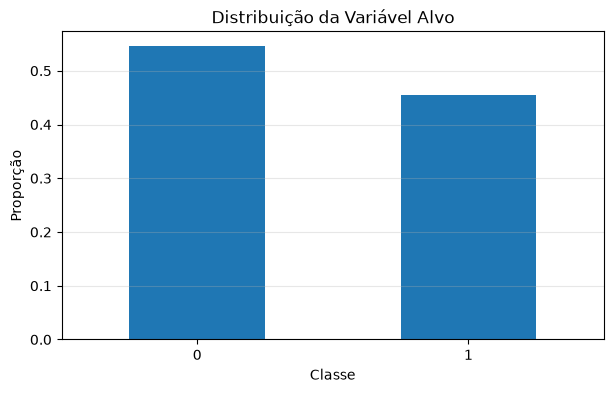

In [4]:
target_dist = df[target_col].value_counts(normalize=True).sort_index()

display(target_dist.to_frame("proporcao"))

fig, ax = plt.subplots(figsize=(7, 4))

target_dist.plot(kind="bar", ax=ax)

ax.set_title("Distribuição da Variável Alvo")
ax.set_xlabel("Classe")
ax.set_ylabel("Proporção")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

fig.savefig(IMAGES_DIR / "modelagem_distribuicao_target.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

## 5. Split temporal

Como os dados são temporais, não usamos divisão aleatória.

Em um cenário real, o modelo é treinado com dados do passado e avaliado em um período posterior. Por isso, usamos um **split temporal** com aproximadamente 80% das datas para treino e 20% para teste.

In [5]:
df_model = df[
    ["data_pregao", "ticker"] + feature_cols + [target_col]
].copy()

df_model = df_model.sort_values("data_pregao").reset_index(drop=True)

datas_unicas = np.array(sorted(df_model["data_pregao"].unique()))
cutoff_idx = int(len(datas_unicas) * 0.8)
cutoff_date = datas_unicas[cutoff_idx]

train_df = df_model[df_model["data_pregao"] < cutoff_date].copy()
test_df = df_model[df_model["data_pregao"] >= cutoff_date].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Data de corte:", cutoff_date)
print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

display(
    pd.DataFrame({
        "base": ["treino", "teste"],
        "data_inicial": [train_df["data_pregao"].min(), test_df["data_pregao"].min()],
        "data_final": [train_df["data_pregao"].max(), test_df["data_pregao"].max()],
        "linhas": [len(train_df), len(test_df)],
        "taxa_classe_1": [y_train.mean(), y_test.mean()],
    })
)

Data de corte: 2024-06-04 00:00:00
Treino: (45640, 17) (45640,)
Teste: (11560, 17) (11560,)


,base,data_inicial,data_final,linhas,taxa_classe_1
0,treino,2019-01-11,2024-06-03,45640,0.4646
1,teste,2024-06-04,2025-10-02,11560,0.4132


## 6. Modelos avaliados

Foram avaliados três modelos com níveis diferentes de complexidade:

| Modelo | Papel no projeto |
|---|---|
| Regressão Logística | baseline simples e interpretável |
| Árvore de Decisão | modelo não linear e explicável |
| Random Forest | ensemble robusto e útil para ranking probabilístico |

A métrica de maior interesse é o desempenho na classe `1`, pois ela representa os ativos que superaram o benchmark.

In [6]:
modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

modelos

{'Regressão Logística': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', LogisticRegression(max_iter=1000, random_state=42))]),
 'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=8, min_samples_leaf=20, n_estimators=200,
                        n_jobs=-1, random_state=42)}

## 7. Função de avaliação

A função abaixo treina o modelo, calcula métricas, exibe o relatório de classificação, gera matriz de confusão e salva a imagem em `images/`.

As principais métricas analisadas são:

- `accuracy`;
- `precision_classe_1`;
- `recall_classe_1`;
- `f1_classe_1`;
- `roc_auc`.

In [7]:
def normalizar_nome_arquivo(nome: str) -> str:
    return (
        nome.lower()
        .replace(" ", "_")
        .replace("ã", "a")
        .replace("á", "a")
        .replace("é", "e")
        .replace("ê", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ç", "c")
    )


def avaliar_modelo(nome_modelo, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    resultados = {
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_classe_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_classe_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_classe_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc,
    }

    print(f"===== {nome_modelo} =====")
    print(resultados)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, values_format="d")

    ax.set_title(f"Matriz de Confusão - {nome_modelo}")

    nome_arquivo = normalizar_nome_arquivo(nome_modelo)
    fig.savefig(
        IMAGES_DIR / f"matriz_confusao_{nome_arquivo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    display(fig)
    plt.close(fig)

    return resultados

## 8. Treinamento e avaliação dos modelos

Nesta etapa os modelos são treinados no período de treino e avaliados no período de teste.

===== Regressão Logística =====
{'modelo': 'Regressão Logística', 'accuracy': 0.5903114186851212, 'precision_classe_1': 0.5162311955661124, 'recall_classe_1': 0.13648733514758216, 'f1_classe_1': 0.21589403973509932, 'roc_auc': 0.5425455177057767}

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.91      0.72      6783
           1       0.52      0.14      0.22      4777

    accuracy                           0.59     11560
   macro avg       0.56      0.52      0.47     11560
weighted avg       0.57      0.59      0.51     11560



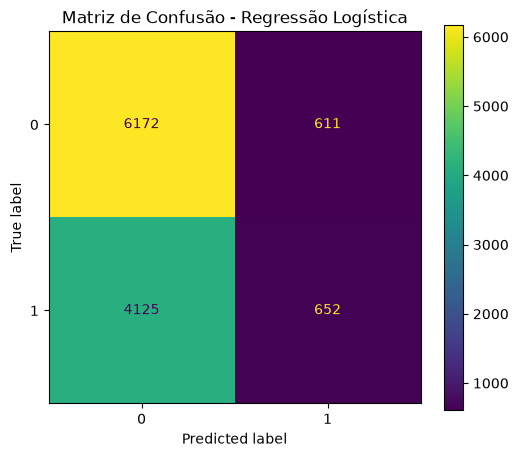

===== Árvore de Decisão =====
{'modelo': 'Árvore de Decisão', 'accuracy': 0.5849480968858132, 'precision_classe_1': 0.49726205997392436, 'recall_classe_1': 0.39920452166631776, 'f1_classe_1': 0.4428704133766837, 'roc_auc': 0.5476508353966841}

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.72      0.67      6783
           1       0.50      0.40      0.44      4777

    accuracy                           0.58     11560
   macro avg       0.56      0.56      0.56     11560
weighted avg       0.57      0.58      0.58     11560



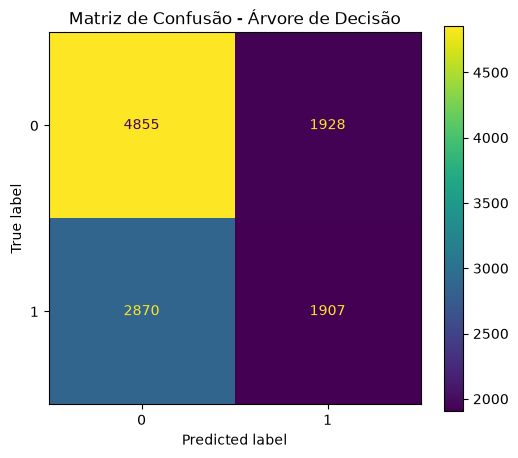

===== Random Forest =====
{'modelo': 'Random Forest', 'accuracy': 0.5840830449826989, 'precision_classe_1': 0.49446626204926813, 'recall_classe_1': 0.2899309189868118, 'f1_classe_1': 0.3655318025864344, 'roc_auc': 0.5422327475771772}

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.79      0.69      6783
           1       0.49      0.29      0.37      4777

    accuracy                           0.58     11560
   macro avg       0.55      0.54      0.53     11560
weighted avg       0.56      0.58      0.56     11560



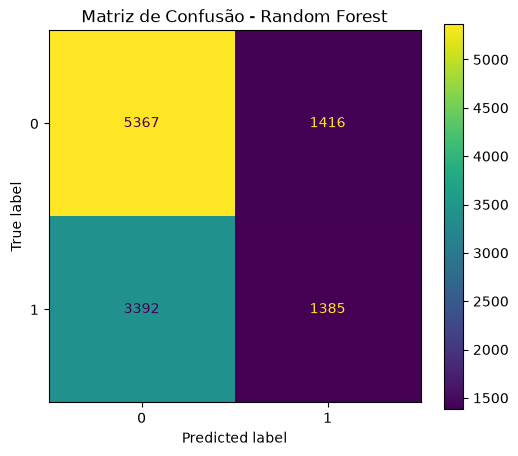

,modelo,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc
0,Árvore de Decisão,0.5849,0.4973,0.3992,0.4429,0.5477
1,Random Forest,0.5841,0.4945,0.2899,0.3655,0.5422
2,Regressão Logística,0.5903,0.5162,0.1365,0.2159,0.5425


In [8]:
resultados = []

for nome_modelo, model in modelos.items():
    resultado = avaliar_modelo(
        nome_modelo,
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )
    resultados.append(resultado)

df_resultados = (
    pd.DataFrame(resultados)
    .sort_values(by="f1_classe_1", ascending=False)
    .reset_index(drop=True)
)

df_resultados.to_csv(TABLES_DIR / "comparacao_modelos.csv", index=False)

df_resultados

## 9. Comparação visual dos modelos

O gráfico abaixo compara os modelos em diferentes métricas.

Para este projeto, o `f1_classe_1` é especialmente importante, pois equilibra precision e recall para a classe dos ativos que superaram o benchmark.

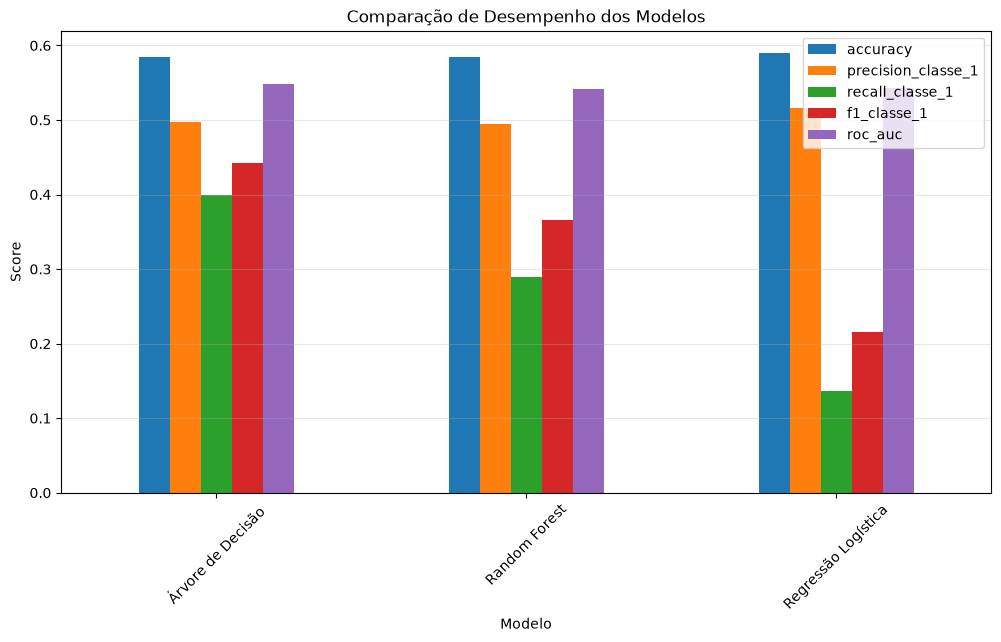

In [9]:
metricas_plot = [
    "accuracy",
    "precision_classe_1",
    "recall_classe_1",
    "f1_classe_1",
    "roc_auc",
]

fig, ax = plt.subplots(figsize=(12, 6))

df_resultados.set_index("modelo")[metricas_plot].plot(kind="bar", ax=ax)

ax.set_title("Comparação de Desempenho dos Modelos")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

fig.savefig(IMAGES_DIR / "comparacao_modelos.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

## 10. Escolha do modelo principal

O modelo principal será escolhido pelo melhor `f1_classe_1`, pois essa métrica equilibra:

- a capacidade de capturar ativos que realmente superam o benchmark;
- a qualidade das classificações positivas.

Além disso, manteremos o Random Forest como modelo auxiliar de score, pois ele fornece probabilidades úteis para ranking.

In [10]:
modelo_principal_nome = df_resultados.sort_values("f1_classe_1", ascending=False).iloc[0]["modelo"]
modelo_principal = modelos[modelo_principal_nome]

modelo_score_nome = "Random Forest"
modelo_score = modelos[modelo_score_nome]

print("Modelo principal:", modelo_principal_nome)
print("Modelo auxiliar de score:", modelo_score_nome)

Modelo principal: Árvore de Decisão
Modelo auxiliar de score: Random Forest


## 11. Importância das variáveis

A análise de importância das variáveis ajuda a entender quais fatores mais contribuíram para os modelos baseados em árvore.

Essa etapa é essencial para transformar o resultado técnico em interpretação de negócio.

,importancia
volume_medio_63d,0.1255
volatilidade_126d,0.1198
volatilidade_63d,0.0889
retorno_252d,0.0761
retorno_126d,0.0756
volume_medio_21d,0.0734
distancia_maxima_252d,0.0711
amplitude_media_21d,0.0710
drawdown_252d,0.0657
negocios_medio_21d,0.0592


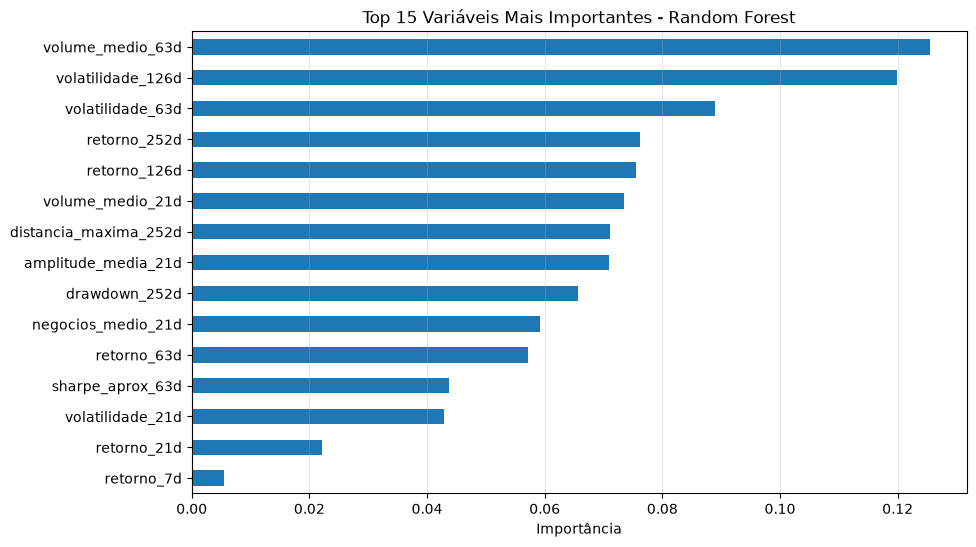

In [11]:
def plot_feature_importance(importances, titulo, nome_arquivo, top_n=15):
    fig, ax = plt.subplots(figsize=(10, 6))

    importances.head(top_n).sort_values().plot(kind="barh", ax=ax)

    ax.set_title(titulo)
    ax.set_xlabel("Importância")
    ax.grid(axis="x", alpha=0.3)

    fig.savefig(IMAGES_DIR / nome_arquivo, dpi=300, bbox_inches="tight")

    display(fig)
    plt.close(fig)


# Random Forest
importances_rf = pd.Series(
    modelos["Random Forest"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importances_rf.to_csv(TABLES_DIR / "feature_importance_random_forest.csv")

display(importances_rf.head(15).to_frame("importancia"))

plot_feature_importance(
    importances_rf,
    "Top 15 Variáveis Mais Importantes - Random Forest",
    "feature_importance_random_forest.png"
)

,importancia
volatilidade_126d,0.2425
volume_medio_63d,0.2211
drawdown_252d,0.1405
retorno_126d,0.0979
retorno_252d,0.0784
retorno_63d,0.0780
volume_medio_21d,0.0343
amplitude_media_21d,0.0335
negocios_medio_21d,0.0248
volatilidade_63d,0.0247


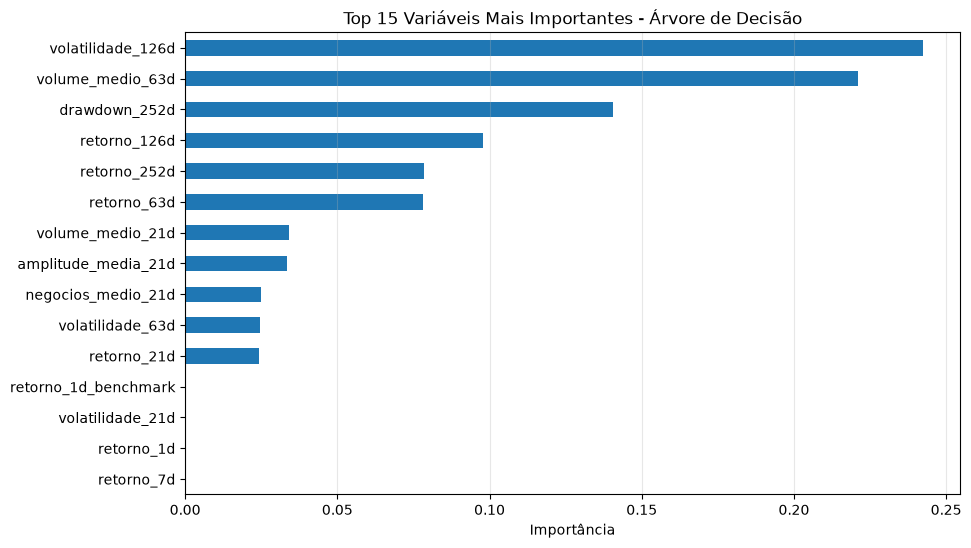

In [12]:
# Árvore de Decisão
importances_tree = pd.Series(
    modelos["Árvore de Decisão"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importances_tree.to_csv(TABLES_DIR / "feature_importance_arvore_decisao.csv")

display(importances_tree.head(15).to_frame("importancia"))

plot_feature_importance(
    importances_tree,
    "Top 15 Variáveis Mais Importantes - Árvore de Decisão",
    "feature_importance_arvore_decisao.png"
)

### Interpretação das importâncias

As variáveis mais relevantes tendem a estar ligadas a:

- liquidez;
- volatilidade;
- drawdown;
- retornos acumulados de médio e longo prazo.

Isso sugere que a superação futura do benchmark está mais associada a características estruturais do ativo do que a oscilações de curtíssimo prazo.

## 12. Score probabilístico no conjunto de teste

Além da classificação `0` ou `1`, usamos a probabilidade estimada pelo Random Forest para criar um ranking de ativos.

Essa abordagem é mais próxima de uma aplicação real: em vez de dizer apenas "recomenda/não recomenda", o modelo ajuda a priorizar ativos para análise.

In [13]:
test_result = test_df.copy()

test_result["proba_superar_benchmark"] = modelo_score.predict_proba(X_test)[:, 1]
test_result["predicao"] = modelo_score.predict(X_test)

test_result.sort_values("proba_superar_benchmark", ascending=False).head(20)

,data_pregao,ticker,retorno_1d,retorno_7d,retorno_21d,retorno_63d,retorno_126d,retorno_252d,volatilidade_21d,volatilidade_63d,volatilidade_126d,volume_medio_21d,volume_medio_63d,negocios_medio_21d,amplitude_media_21d,drawdown_252d,distancia_maxima_252d,sharpe_aprox_63d,retorno_1d_benchmark,target_supera_benchmark_60d,proba_superar_benchmark,predicao
47494,2024-08-15,BRFS3,0.0170,0.1501,0.0584,0.2350,0.6732,1.4030,0.4001,0.3445,0.4059,15861239333.3333,17160424209.5238,17942.7143,0.0332,0.0000,0.0000,0.6822,0.0062,1,0.6254,1
47665,2024-08-22,BRFS3,-0.0123,0.1452,0.2361,0.3475,0.9044,1.5206,0.2938,0.3511,0.4065,16385657104.7619,17176078722.2222,18844.9524,0.0327,-0.0123,-0.0123,0.9896,-0.0088,1,0.6234,1
46316,2024-07-01,BRFS3,0.0154,0.1334,0.2390,0.4387,0.6669,1.6551,0.3510,0.4330,0.4223,16282476971.4286,20345450555.5556,19687.1905,0.0303,0.0000,0.0000,1.0132,0.0058,1,0.6210,1
47595,2024-08-20,BRFS3,0.0059,0.1582,0.2038,0.3222,0.8234,1.4660,0.2907,0.3481,0.4074,15852474604.7619,17199390796.8254,18518.5238,0.0314,0.0000,0.0000,0.9256,0.0035,1,0.6193,1
47614,2024-08-21,BRFS3,0.0248,0.1913,0.2431,0.3536,0.8781,1.5900,0.2890,0.3503,0.4081,16082689300.0000,17208579825.3968,18600.5238,0.0319,0.0000,0.0000,1.0093,0.0023,1,0.6189,1
47522,2024-08-16,BRFS3,0.0163,0.1627,0.1677,0.2366,0.7173,1.4670,0.2694,0.3447,0.4057,15389141952.3810,17114798190.4762,17719.0476,0.0316,0.0000,0.0000,0.6865,-0.0015,1,0.6182,1
47532,2024-08-19,BRFS3,0.0391,0.1722,0.2030,0.2876,0.8152,1.3979,0.2908,0.3517,0.4075,15344409290.4762,17197555726.9841,18151.4286,0.0315,0.0000,0.0000,0.8178,0.0130,1,0.6144,1
47684,2024-08-23,BRFS3,-0.0202,0.0715,0.1967,0.3032,0.7980,1.5368,0.3121,0.3543,0.4054,17041554195.2381,17408627877.7778,19312.6190,0.0340,-0.0323,-0.0323,0.8556,0.0031,0,0.6134,1
46352,2024-07-02,BRFS3,0.0256,0.1489,0.2619,0.4784,0.7096,1.8446,0.3546,0.4345,0.4233,16762590938.0952,20470441611.1111,19949.3333,0.0306,0.0000,0.0000,1.1011,0.0021,0,0.6134,1
50238,2024-12-06,BRFS3,0.0011,0.1517,0.0977,0.1234,0.4905,1.0403,0.4676,0.3668,0.3678,27418718071.4286,19376873314.2857,23461.5238,0.0378,0.0000,0.0000,0.3364,-0.0165,0,0.6132,1


## 13. Avaliação por faixas de probabilidade

Aqui verificamos se as faixas de maior probabilidade prevista pelo modelo apresentam, na prática, maior taxa real de superação do benchmark.

Se isso acontecer, o modelo tem valor como ferramenta de **ranking e priorização**.

In [14]:
faixa_labels = [
    "Muito baixa",
    "Baixa",
    "Média",
    "Alta",
    "Muito alta",
]

# O rank(method="first") evita problemas de valores repetidos no qcut.
test_result["faixa_probabilidade"] = pd.qcut(
    test_result["proba_superar_benchmark"].rank(method="first"),
    q=5,
    labels=faixa_labels
)

analise_faixas = (
    test_result.groupby("faixa_probabilidade", observed=False)
    .agg(
        qtd_observacoes=(target_col, "count"),
        taxa_superacao_real=(target_col, "mean"),
        probabilidade_media=("proba_superar_benchmark", "mean"),
    )
    .reset_index()
)

analise_faixas.to_csv(TABLES_DIR / "analise_faixas_probabilidade.csv", index=False)

analise_faixas

,faixa_probabilidade,qtd_observacoes,taxa_superacao_real,probabilidade_media
0,Muito baixa,2312,0.4066,0.3387
1,Baixa,2312,0.3672,0.4040
2,Média,2312,0.3785,0.4542
3,Alta,2312,0.4234,0.4920
4,Muito alta,2312,0.4905,0.5255


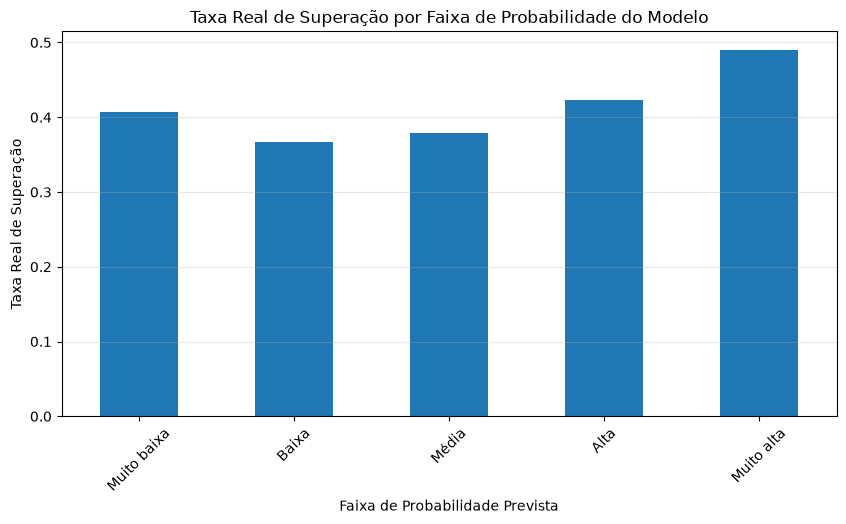

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

analise_faixas.plot(
    x="faixa_probabilidade",
    y="taxa_superacao_real",
    kind="bar",
    ax=ax,
    legend=False,
)

ax.set_title("Taxa Real de Superação por Faixa de Probabilidade do Modelo")
ax.set_xlabel("Faixa de Probabilidade Prevista")
ax.set_ylabel("Taxa Real de Superação")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

fig.savefig(
    IMAGES_DIR / "taxa_superacao_por_faixa_probabilidade.png",
    dpi=300,
    bbox_inches="tight"
)

display(fig)
plt.close(fig)

## 14. Ranking final por ativo

Nesta etapa agregamos as previsões do conjunto de teste por ativo.

O objetivo é identificar quais ativos receberam maior probabilidade média de superar o benchmark no período de teste.

In [16]:
ranking_teste = (
    test_result.groupby("ticker")
    .agg(
        probabilidade_media=("proba_superar_benchmark", "mean"),
        taxa_real_superacao=(target_col, "mean"),
        qtd_observacoes=(target_col, "count"),
    )
    .reset_index()
    .sort_values("probabilidade_media", ascending=False)
)

ranking_teste.to_csv(TABLES_DIR / "ranking_ativos_probabilidade_teste.csv", index=False)

ranking_teste.head(15)

,ticker,probabilidade_media,taxa_real_superacao,qtd_observacoes
10,ELET6,0.5121,0.4554,336
5,BRFS3,0.5115,0.3750,328
32,VIVA3,0.5108,0.6250,336
30,UGPA3,0.5063,0.2679,336
7,CPFE3,0.5010,0.5565,336
29,TIMS3,0.4982,0.6429,336
25,SANB11,0.4941,0.4851,336
16,KLBN11,0.4934,0.2411,336
6,CCRO3,0.4907,0.2555,227
22,RADL3,0.4889,0.3125,336


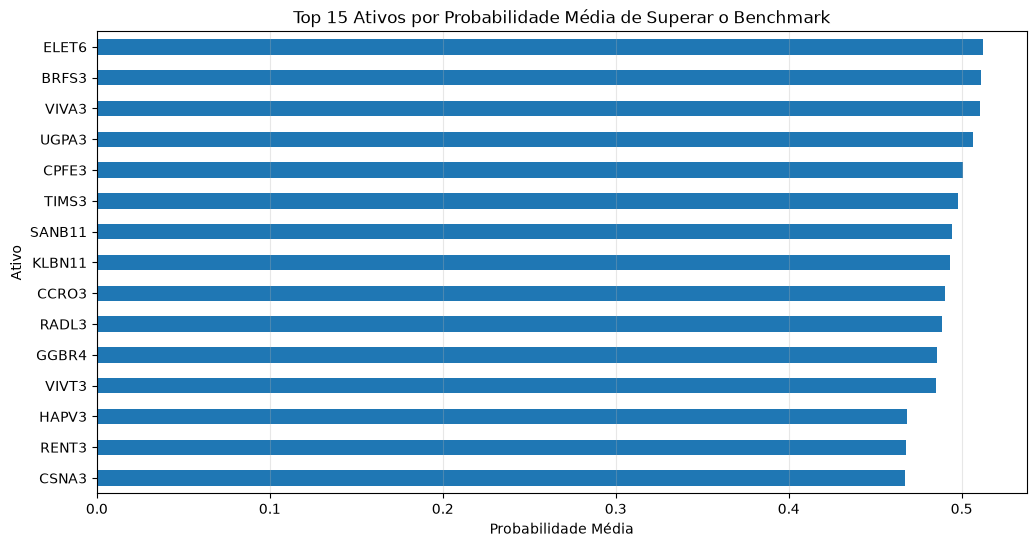

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

ranking_teste.head(15).sort_values("probabilidade_media").plot(
    x="ticker",
    y="probabilidade_media",
    kind="barh",
    ax=ax,
    legend=False,
)

ax.set_title("Top 15 Ativos por Probabilidade Média de Superar o Benchmark")
ax.set_xlabel("Probabilidade Média")
ax.set_ylabel("Ativo")
ax.grid(axis="x", alpha=0.3)

fig.savefig(IMAGES_DIR / "top_ativos_probabilidade_media.png", dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

## 15. Exportação dos resultados finais

Nesta etapa salvamos as principais saídas do notebook para serem usadas no README, relatório e apresentação final.

In [18]:
# Exportações adicionais
test_result.to_csv(TABLES_DIR / "previsoes_conjunto_teste.csv", index=False)

print("Arquivos salvos em:")
print("- Gráficos:", IMAGES_DIR.resolve())
print("- Tabelas:", TABLES_DIR.resolve())

print("\nTabelas geradas:")
for file in sorted(TABLES_DIR.glob("*.csv")):
    print("-", file.name)

print("\nImagens geradas:")
for file in sorted(IMAGES_DIR.glob("*.png")):
    print("-", file.name)

Arquivos salvos em:
- Gráficos: C:\Users\Mateus\Documents\Ebac Tarefa\Projeto semantix\projeto-semantix-fintech\images
- Tabelas: C:\Users\Mateus\Documents\Ebac Tarefa\Projeto semantix\projeto-semantix-fintech\reports\tables

Tabelas geradas:
- analise_faixas_probabilidade.csv
- comparacao_modelos.csv
- drawdown_medio_por_ativo.csv
- feature_importance_arvore_decisao.csv
- feature_importance_random_forest.csv
- liquidez_media_por_ativo.csv
- perfil_ativos_suitability.csv
- previsoes_conjunto_teste.csv
- ranking_ativos_probabilidade_teste.csv
- ranking_superacao_benchmark.csv
- retorno_medio_futuro_60d.csv
- risco_medio_por_ativo.csv
- risco_retorno_por_ativo.csv

Imagens geradas:
- comparacao_modelos.png
- distribuicao_perfil_ativos.png
- distribuicao_target.png
- feature_importance_arvore_decisao.png
- feature_importance_random_forest.png
- mapa_risco_retorno.png
- mapa_risco_retorno_sem_outliers.png
- matriz_confusao_arvore_de_decisao.png
- matriz_confusao_random_forest.png
- matriz_

## 16. Conclusões da modelagem

A modelagem mostrou que a previsão de superação de benchmark é um problema difícil, com sinal preditivo moderado. Esse comportamento é esperado em dados financeiros, que são ruidosos e sujeitos a mudanças de regime.

Ainda assim, os modelos entregaram valor analítico:

1. A **Árvore de Decisão** apresentou o melhor equilíbrio para a classe positiva, sendo escolhida como modelo principal.
2. O **Random Forest** foi útil como modelo auxiliar de score e interpretação.
3. As variáveis mais importantes ficaram ligadas a liquidez, volatilidade, drawdown e retornos de médio/longo prazo.
4. A análise por faixas de probabilidade indicou que o modelo pode ser usado como ferramenta de priorização, e não como recomendação automática.

Portanto, a melhor aplicação da solução é como uma camada de apoio à decisão para uma fintech/corretora, auxiliando na triagem de ativos e na construção de recomendações compatíveis com critérios de risco e suitability.